# RQ5.ipynb

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [6]:

df = pd.read_csv('C:/Users/vrund/Downloads/ML/amazon_sales_2025_INR.csv')
df = df.select_dtypes(include=[np.number]).dropna()
target = df.columns[-1]
X = df.drop(target, axis=1)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


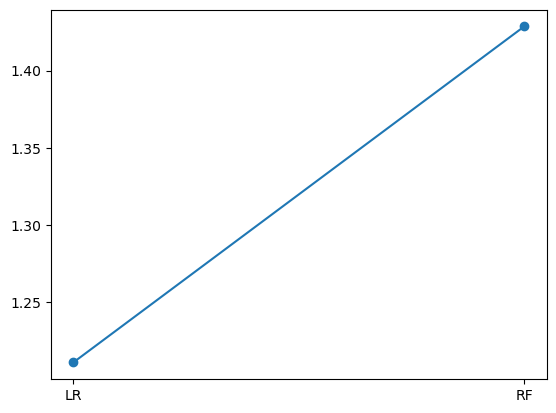

In [7]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

models = {
    "LR": LinearRegression(),
    "RF": RandomForestRegressor()
}

metrics = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics.append([name,
                    mean_absolute_error(y_test,pred),
                    np.sqrt(mean_squared_error(y_test,pred)),
                    r2_score(y_test,pred)])

df_res = pd.DataFrame(metrics, columns=["Model","MAE","RMSE","R2"])
df_res.to_csv("RQ5_table.csv", index=False)

plt.figure()
plt.plot(df_res["Model"], df_res["MAE"], marker='o')
plt.savefig("RQ5_figure.pdf")
